In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [33]:
df = pd.read_csv("Hogaya.csv")

In [34]:
df.drop(['Start_Time','End_Time'],inplace = True,axis = 1)

In [3]:
clf = setup(data=df, target='Severity',preprocess=True)

,Description,Value
0,Session id,6714
1,Target,Severity
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3"
4,Original data shape,"(498517, 27)"
5,Transformed data shape,"(498517, 29)"
6,Transformed train set shape,"(348961, 29)"
7,Transformed test set shape,"(149556, 29)"
8,Numeric features,12
9,Categorical features,9


In [4]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7964,0.7368,0.7964,0.7499,0.7079,0.0079,0.0459,11.9180
et,Extra Trees Classifier,0.7962,0.7693,0.7962,0.7462,0.7082,0.0094,0.0469,12.8070
dummy,Dummy Classifier,0.7961,0.5000,0.7961,0.6338,0.7057,0.0000,0.0000,2.9360
lr,Logistic Regression,0.7960,0.0000,0.7960,0.7326,0.7105,0.0183,0.0582,27.1100
lda,Linear Discriminant Analysis,0.7953,0.0000,0.7953,0.6822,0.7073,0.0064,0.0289,3.2790
ridge,Ridge Classifier,0.7950,0.0000,0.7950,0.6671,0.7064,0.0037,0.0169,3.0280
gbc,Gradient Boosting Classifier,0.7947,0.0000,0.7947,0.7158,0.7101,0.0167,0.0487,98.3280
qda,Quadratic Discriminant Analysis,0.7940,0.0000,0.7940,0.7675,0.7074,0.0117,0.0386,3.3270
knn,K Neighbors Classifier,0.7766,0.6897,0.7766,0.7280,0.7414,0.1583,0.1727,64.4020
ada,Ada Boost Classifier,0.7764,0.0000,0.7764,0.7106,0.7015,0.0312,0.0613,9.3090


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=6714, verbose=0,
                       warm_start=False)

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
X = df.drop("Severity", axis=1)

In [37]:
y = df["Severity"]

In [45]:
from sklearn.model_selection import train_test_split 
X_train, X_test,y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2,stratify=y)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE",Counter(y_train))
print("After SMOTE",Counter(y_train_res))
class_weights = {1:2,2:1,3:3,4:4}
rf = RandomForestClassifier(n_estimators=300,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1)
model = rf.fit(X_train_res, y_train_res)

Before SMOTE Counter({2: 317496, 3: 67588, 4: 10320, 1: 3409})
After SMOTE Counter({2: 317496, 3: 317496, 4: 317496, 1: 317496})


In [46]:
#model = rf.fit(X_train, y_train)

In [47]:
model.get_params()
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8266970231886384

Confusion Matrix:
 [[  512   271    64     5]
 [  227 71534  6803   811]
 [  124  6771  9718   284]
 [    5  1633   281   661]]

Classification Report:
               precision    recall  f1-score   support

           1       0.59      0.60      0.60       852
           2       0.89      0.90      0.90     79375
           3       0.58      0.58      0.58     16897
           4       0.38      0.26      0.30      2580

    accuracy                           0.83     99704
   macro avg       0.61      0.58      0.59     99704
weighted avg       0.82      0.83      0.82     99704



In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

              Feature  Importance
25     Source_Source2    0.173867
0        Distance(mi)    0.167151
13               Year    0.118008
12   Duration_Minutes    0.106008
14              Month    0.041394
1      Temperature(F)    0.038938
3        Pressure(in)    0.035279
6   Precipitation(in)    0.033860
2         Humidity(%)    0.033227
16               Hour    0.027416


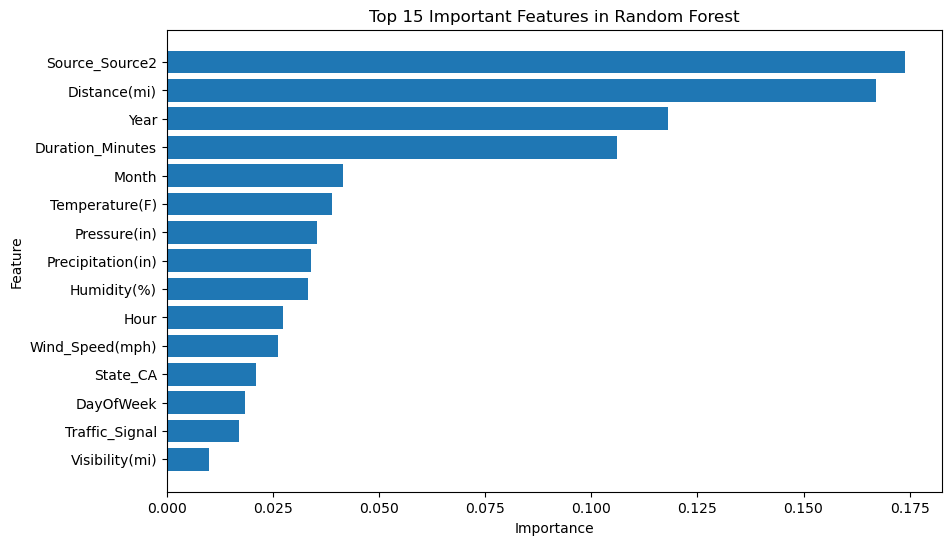

In [50]:
plt.figure(figsize=(10,6))
plt.barh(feature_importances['Feature'][:15], feature_importances['Importance'][:15])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features in Random Forest")
plt.show()